<a href="https://colab.research.google.com/github/froyglezzz/Quimica-Cuantica/blob/main/Actividad_Molecula_de_agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install "qiskit==1.2.4" \
"qiskit-nature==0.7.2" \
"qiskit-aer==0.15.1" \
"qiskit-algorithms==0.3.1" \
pyscf \
matplotlib \
numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 11.2 MB/s eta 0:00:00


In [14]:
# Nombre: H2O
# Objetivo: calcula las posiciones relativas de los átomo
# de hidrógeno en una molécula de agua
# primero importamos lo necesario
import numpy as np
import pylab
from qiskit import *
from qiskit_aer.primitives import Sampler
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.mappers import JordanWignerMapper
import matplotlib.pyplot as plt

In [9]:
#Definimos nuestra molécula considerando una posición variable
molecule = 'H {0} 0.7567 0.0; H {0} -0.7567 0.0; O 0.0 0.0 0.0'

#Probamos para una distancia
d = 0.5
driver = PySCFDriver(molecule.format(d),charge=0, spin=0, basis='sto3g')
qmolecule = driver.run()
#aplicamos el hamiltoniano
hamiltonian = qmolecule.hamiltonian
#obtenemos la energia de repulsión
repulsion = hamiltonian.nuclear_repulsion_energy
#ahora obtenemos el valor de la energía del estado base
solver = GroundStateEigensolver(JordanWignerMapper(),NumPyMinimumEigensolver(),)
result = solver.solve(qmolecule)
base = result.total_energies[0]
print('Energia estado base:' , base)
print('Energía de repulsión: ', repulsion)
print(result)

Energia estado base: -74.98626649476576
Energía de repulsión:  9.684957576396796
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -84.671224071163
  - computed part:      -84.671224071163
~ Nuclear repulsion energy (Hartree): 9.684957576397
> Total ground state energy (Hartree): -74.986266494766
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 10.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [1.88972612  0.0  0.0]
 
  0: 
  * Electronic dipole moment (a.u.): [1.244330894441  0.0  0.0]
    - computed part:      [1.244330894441  0.0  0.0]
  > Dipole moment (a.u.): [0.645395225559  0.0  0.0]  Total: 0.645395225559
                 (debye): [1.640430882106  0.0  0.0]  Total: 1.640430882106
 


In [12]:
#Tambien definimos nuestro rango y paso de análisis de distancias
distancias = np.arange(0.5,1.5,0.1)
#Definimos nuestros vectores de almacenamiento
repulsiones = []
bases = []
#Con el ciclo vamos a ir variando la distancia y midiendo los valores
#de energía de repulsión y energia del estado base
for i,d in enumerate(distancias):
  print('step',i)
  driver = PySCFDriver(molecule.format(d),basis='sto3g')
  qmolecule = driver.run()
  hamiltonian = qmolecule.hamiltonian
  repulsion = hamiltonian.nuclear_repulsion_energy
  repulsiones.append(repulsion)
  solver = GroundStateEigensolver(JordanWignerMapper(),NumPyMinimumEigensolver(),)
  result = solver.solve(qmolecule)
  base = result.total_energies[0]
  bases.append(base)
  #imprimimos las energias
  print('Energía de repulsión: ', repulsion)
  print('Energia estado base:' , base)
  print('Distancia:' , d)

step 0
Energía de repulsión:  9.684957576396796
Energia estado base: -74.98626649476567
Distancia: 0.5
step 1
Energía de repulsión:  9.117137453545821
Energia estado base: -75.01513242480463
Distancia: 0.6
step 2
Energía de repulsión:  8.56333124026553
Energia estado base: -75.02306343372067
Distancia: 0.7
step 3
Energía de repulsión:  8.038544103192757
Energia estado base: -75.01304235405327
Distancia: 0.7999999999999999
step 4
Energía de repulsión:  7.550343334961674
Energia estado base: -74.98982627822696
Distancia: 0.8999999999999999
step 5
Energía de repulsión:  7.101354150424038
Energia estado base: -74.95841088358391
Distancia: 0.9999999999999999
step 6
Energía de repulsión:  6.691201910041517
Energia estado base: -74.92307611755886
Distancia: 1.0999999999999999
step 7
Energía de repulsión:  6.317855182291407
Energia estado base: -74.88701821265937
Distancia: 1.1999999999999997
step 8
Energía de repulsión:  5.978485752608668
Energia estado base: -74.85242838692703
Distancia: 1.2

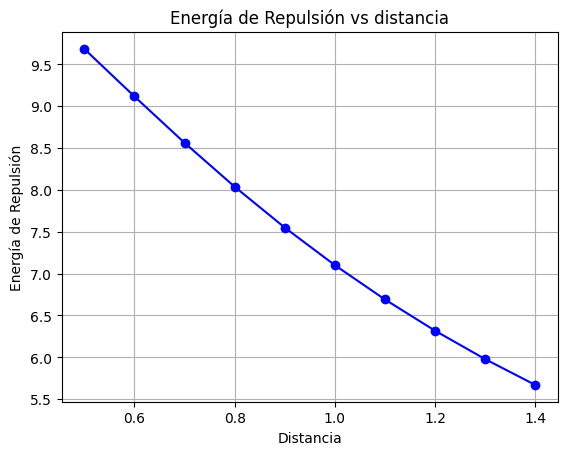

In [15]:
# graficamos las energías de repulsión
plt.plot(distancias, repulsiones, marker='o', linestyle='-', color='b')
plt.title('Energía de Repulsión vs distancia')
plt.xlabel('Distancia')
plt.ylabel('Energía de Repulsión')
plt.grid(True)
plt.show()

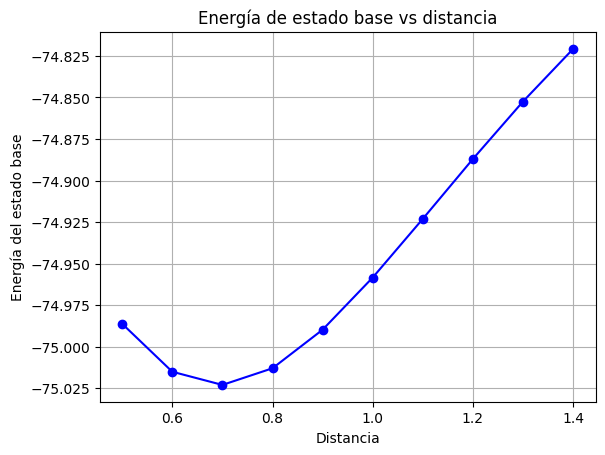

In [16]:
#graficamos las energías del estado base
plt.plot(distancias, bases, marker='o', linestyle='-', color='b')
plt.title('Energía de estado base vs distancia')
plt.xlabel('Distancia')
plt.ylabel('Energía del estado base')
plt.grid(True)
plt.show()

In [23]:
# Install py3Dmol if not already installed
try:
    import py3Dmol
except ImportError:
    %pip install py3Dmol
    import py3Dmol

from pyscf import gto, scf, tools
import numpy as np

# Use a distance from the calculated range, e.g., d=0.7 (index 2 in 'distancias')
# This corresponds to one of the calculated points from the previous cells.
d = 0.7 # From distancias array, which yielded a relatively low energy

# Define the molecule geometry for PySCF.
# The 'molecule' variable from previous cells was 'H {0} 0.7567 0.0; H {0} -0.7567 0.0; O 0.0 0.0 0.0'
# Applying the chosen 'd' value for the {0} placeholder.
pyscf_atom_string = f"H {d} 0.7567 0.0; H {d} -0.7567 0.0; O 0.0 0.0 0.0"

# Create PySCF molecule object
mol = gto.M(atom=pyscf_atom_string, basis='sto3g')

# Perform Restricted Hartree-Fock calculation
mf = scf.RHF(mol).run()

# Get the density matrix from the mean-field object
dm = mf.make_rdm1()

# Generate the electron density cube file
density_cube_filename = 'h2o_density.cube'
tools.cubegen.density(mol, density_cube_filename, dm, nx=50, ny=50, nz=50)

# Generate the Molecular Electrostatic Potential (MEP) cube file
mep_cube_filename = 'h2o_mep.cube'
tools.cubegen.mep(mol, mep_cube_filename, dm, nx=50, ny=50, nz=50)

# Visualize with py3Dmol
view = py3Dmol.view(width=600, height=400)

# Add the molecule model
# Manually construct XYZ string from mol.atom using mol.natm and atom_symbol/atom_coord
xyz_lines = [f"{mol.natm}\nAuto-generated by PySCF"]
for i in range(mol.natm):
    atom_symbol = mol.atom_symbol(i)
    coords_bohr = mol.atom_coord(i)
    coords_angstrom = [c * 0.529177210903 for c in coords_bohr] # Convert bohr to angstrom
    xyz_lines.append(f"{atom_symbol} {coords_angstrom[0]:.4f} {coords_angstrom[1]:.4f} {coords_angstrom[2]:.4f}")
xyz_str = "\n".join(xyz_lines)

view.addModel(xyz_str, 'xyz')
view.setStyle({'sphere':{'radius':0.3}, 'stick':{'radius':0.1}})

# Add the electron density isosurface, colored by MEP
# 'iso' value for electron density isosurface (common values are 0.02, 0.03, 0.04)
# 'colorScheme' maps MEP values to colors: 'bluered' gradient means blue for low values (negative potential) and red for high values (positive potential).
# 'vmax' and 'vmin' define the range of potential values for the color gradient.
view.addSurface('electron_density',
                {'opacity':0.7, 'colorScheme': {'prop':'potential', 'gradient': 'bluered'},
                 'vmax':0.08, 'vmin':-0.08},
                {'cube':density_cube_filename, 'fullCube':mep_cube_filename, 'iso':0.02})

view.zoomTo()
view.show()

converged SCF energy = -74.9614815364255


3Dmol.js failed to load for some reason. Please check your browser console for error messages.